In [1]:
import itertools as iter

import awkward as ak

import dask
import dask_awkward as dak
import hist.dask as hda
import matplotlib.pyplot as plt

# import numba
import numpy as np
import uproot

# import vector as vec
from coffea.analysis_tools import PackedSelection
from coffea.nanoevents import NanoEventsFactory, ScoutingNanoAODSchema
# from hist import Hist


In [2]:
from coffea.lookup_tools import extractor
from coffea.jetmet_tools import FactorizedJetCorrector, JetCorrectionUncertainty
from coffea.jetmet_tools import JECStack, CorrectedJetsFactory

In [3]:
file_list = [line.strip('\n') for line in open("filelists/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] # + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0002.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]



ScoutingNanoAODSchema.warn_missing_crossrefs = False

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[10:11]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "HadronicTops"},
).events()

events = small_events[0:10_000]
#ak.num(small_events, axis=0).compute()

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [4]:
def apply_JEC_MC(ev):
    ext = extractor()
    ext.add_weight_sets(
        [
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L1FastJet_AK4PFPuppi.jec.txt",
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L2Relative_AK4PFPuppi.jec.txt",
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L3Absolute_AK4PFPuppi.jec.txt",
            "* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_L2L3Residual_AK4PFPuppi.jec.txt",
            #"* * corrections/Summer22EE_22Sep2023_V2_MC/Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi.junc.txt",
        ],
    )
    ext.finalize()

    jec_stack_names = [
        "Summer22EE_22Sep2023_V2_MC_L1FastJet_AK4PFPuppi",
        "Summer22EE_22Sep2023_V2_MC_L2Relative_AK4PFPuppi",
        "Summer22EE_22Sep2023_V2_MC_L3Absolute_AK4PFPuppi",
        "Summer22EE_22Sep2023_V2_MC_L2L3Residual_AK4PFPuppi",
        #"Summer22EE_22Sep2023_V2_MC_Uncertainty_AK4PFPuppi",
    ]

    evaluator = ext.make_evaluator()
    jec_inputs = {name: evaluator[name] for name in jec_stack_names}
    jec_stack = JECStack(jec_inputs)

    name_map = jec_stack.blank_name_map
    name_map["JetPt"] = "pt"
    name_map["JetMass"] = "mass"
    name_map["JetEta"] = "eta"
    name_map["JetA"] = "area"

    jets = ev.ScoutingJet

    jets["pt_raw"] = jets["pt"]
    jets["mass_raw"] = jets["mass"]
    jets["rho"] = ak.broadcast_arrays(ev.ScoutingRho, jets.pt)[0]
    name_map["ptGenJet"] = "pt_gen"
    name_map["ptRaw"] = "pt_raw"
    name_map["massRaw"] = "mass_raw"
    name_map["Rho"] = "rho"

    jet_factory = CorrectedJetsFactory(name_map, jec_stack)

    return jet_factory.build(jets)


In [5]:
events["ScoutingJet"] = apply_JEC_MC(events)

In [6]:
truth = events.GenPart[
            (abs(events.GenPart.pdgId) == 24)
              & ( events.GenPart.hasFlags(["isLastCopy","isPrompt"]))
              ]

w_to_jets_cut =(
    (abs(truth.distinctChildren[:,:,0].pdgId) == 1)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 2)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 3)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)
    )

w_truth = truth[w_to_jets_cut]


good_events = events[(ak.num(w_truth, axis=1) > 1)]

In [7]:
w_truth = w_truth[ak.num(w_truth, axis=1) > 1]
w_truth_1 = w_truth[:,0]
w_truth_2 = w_truth[:,1]

truth_b = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]))
    & ((good_events.GenPart.distinctParentIdxG == w_truth_1.distinctParentIdxG)
    | (good_events.GenPart.distinctParentIdxG == w_truth_2.distinctParentIdxG))
    ]

good_events = good_events[
    (ak.num(truth_b, axis=1) > 1)
    & (ak.num(w_truth_1.distinctChildren, axis=1) > 1)
    & (ak.num(w_truth_2.distinctChildren, axis=1) > 1)
    ]

In [8]:
ak.num(good_events,axis=0).compute()

9888

In [9]:
truth = good_events.GenPart[(abs(good_events.GenPart.pdgId) == 24) & ( good_events.GenPart.hasFlags(["isLastCopy","isPrompt"]))]

w_to_jets_cut = (
    (abs(truth.distinctChildren[:,:,0].pdgId) == 1)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 2)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 3)
    | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)
    )
w_truth = truth[w_to_jets_cut]
w_truth = w_truth[ak.num(w_truth, axis=1) > 1]
w_truth_1 = w_truth[:,0]
w_truth_2 = w_truth[:,1]
w_jets_truth_1 = w_truth_1.distinctChildren
w_jets_truth_2 = w_truth_2.distinctChildren

truth_b = good_events.GenPart[
    (abs(good_events.GenPart.pdgId) == 5)
    & ( good_events.GenPart.hasFlags(["isLastCopy"]) )
    & ((good_events.GenPart.distinctParentIdxG == w_truth_1.distinctParentIdxG)
       |(good_events.GenPart.distinctParentIdxG == w_truth_2.distinctParentIdxG) )
    ]

truth_b1 = truth_b[:,0]
truth_b2 = truth_b[:,1]
jet1 = w_jets_truth_1[:,0]
jet2 = w_jets_truth_1[:,1]
jet3 = w_jets_truth_2[:,0]
jet4 = w_jets_truth_2[:,1]

In [9]:
print(ak.num(truth_b1,axis=0))
print(ak.num(truth_b2,axis=0))
print(ak.num(jet1,axis=0))
print(ak.num(jet2,axis=0))
print(ak.num(jet3,axis=0))
print(ak.num(jet4,axis=0))

9888
9888
9888
9888
9888
9888


In [10]:
c1= good_events.ScoutingJet[
    ak.local_index(good_events.ScoutingJet,axis=1)
    == ak.argmin(jet1.delta_r(good_events.ScoutingJet),axis=1)
    ]

c2 = good_events.ScoutingJet[
    ak.local_index(good_events.ScoutingJet,axis=1)
    == ak.argmin(jet2.delta_r(good_events.ScoutingJet),axis=1)
    ]

c3= good_events.ScoutingJet[
    ak.local_index(good_events.ScoutingJet,axis=1)
    == ak.argmin(jet3.delta_r(good_events.ScoutingJet),axis=1)
    ]

c4 = good_events.ScoutingJet[
    ak.local_index(good_events.ScoutingJet,axis=1)
    == ak.argmin(jet4.delta_r(good_events.ScoutingJet),axis=1)
    ]

b1= good_events.ScoutingJet[
    ak.local_index(good_events.ScoutingJet,axis=1)
    == ak.argmin(truth_b1.delta_r(good_events.ScoutingJet),axis=1)
    ]

b1= good_events.ScoutingJet[
    ak.local_index(good_events.ScoutingJet,axis=1)
    == ak.argmin(truth_b2.delta_r(good_events.ScoutingJet),axis=1)
    ]

In [23]:
arr = []
for truth_jet in [jet1,jet2,jet3,jet4,truth_b1,truth_b2]:
    temp_cand = good_events.ScoutingJet[
        ak.local_index(good_events.ScoutingJet,axis=1)
        == ak.argmin(truth_jet.delta_r(good_events.ScoutingJet),axis=1)
        ].pt
    temp_truth = truth_jet.pt
    arr.append(np.array(ak.flatten((temp_cand/temp_truth).compute())))

arr

[array([0.97915596, 1.5840274 , 0.84784013, ..., 1.0076356 , 0.8963214 ,
        1.9858705 ], dtype=float32),
 array([0.86317074, 1.7926742 , 0.98717844, ..., 0.99649656, 0.7284039 ,
        1.0064244 ], dtype=float32),
 array([0.7852861, 0.9822771, 1.4106594, ..., 0.768738 , 1.5472156,
        1.4408293], dtype=float32),
 array([0.927655 , 1.4119375, 0.6761378, ..., 2.3396652, 1.1890018,
        0.958321 ], dtype=float32),
 array([0.90891206, 1.3665129 , 0.9986341 , ..., 2.1288807 , 1.0108993 ,
        3.4637501 ], dtype=float32),
 array([0.7667821, 1.0225643, 1.21555  , ..., 1.2873999, 1.104758 ,
        0.6714225], dtype=float32)]

In [24]:
total = np.concatenate(arr)

Text(0.5, 0, 'pt_corr/matched_genpT')

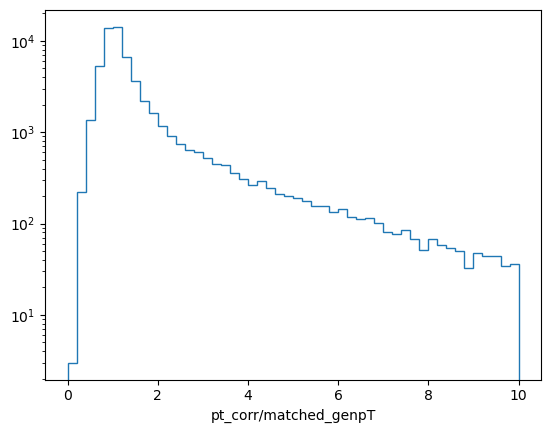

In [31]:
plt.hist(
    total,
    bins=50,
    range=(0,10),
    histtype="step",
         )

plt.yscale("log")
plt.xlabel("pt_corr/matched_genpT")